# Data Cleaning and EDA with Time Series Data


In [92]:
# Import required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [93]:
#use this cell to import additional libraries or define helper functions
import seaborn as sns
import zipfile
import os
import matplotlib.pyplot as plt

## Load and clean your data
The household electric consumption dataset can be downloaded as a zip file here along with a description of the data attributes:
https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption#

First we will load this data into a pandas df and do some initial discovery

In [94]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
# Path to the zip file
zip_file_path = '/content/drive/My Drive/530-IoT/individual+household+electric+power+consumption.zip'

# Extract the contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/extracted_files')

# List the extracted files
extracted_files = os.listdir('/content/extracted_files')
print("Extracted Files:", extracted_files)

# Path to the extracted text file
data_file_path = os.path.join('/content/extracted_files', 'household_power_consumption.txt')

Extracted Files: ['household_power_consumption.txt']


In [96]:
# Load the text file into a DataFrame
df_raw = pd.read_csv(data_file_path, delimiter=';', low_memory=False)

In [97]:
# Display the first few rows
df_raw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [98]:
# Summary Statistics
df_raw.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


Well that's not what we want to see--why is only one column showing up?
Let's check the datatypes

In [99]:
# Check the data types of each column
df_raw.dtypes

,0
Date,object
Time,object
Global_active_power,object
Global_reactive_power,object
Voltage,object
Global_intensity,object
Sub_metering_1,object
Sub_metering_2,object
Sub_metering_3,float64


OK, so only one of our columns came in as the correct data type. We'll get to why that is later, but first let's get everything assigned correctly so that we can use our describe function.

**TODO: combine the 'Date' and 'Time' columns into a column called 'Datetime' and convert it into a datetime datatype. Heads up, the date is not in the standard format...**

**TODO: use the pd.to_numeric function to convert the rest of the columns. You'll need to decide what to do with your errors for the cells that don't convert to numbers**

In [100]:
#make a copy of the raw data so that we can go back and refer to it later
df = df_raw.copy()

In [106]:
# Check Column names
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [109]:
# create the 'Datetime' column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

In [110]:
#convert all data columns to numeric types
data_columns = df.columns.difference(['Date', 'Time', 'Datetime'])
df[data_columns] = df[data_columns].apply(pd.to_numeric, errors='coerce')

Let's use the Datetime column to turn the Date and Time columns into date and time dtypes.

In [111]:
# Convert 'Date' and 'Time' columns to appropriate types
if 'Datetime' in df.columns:
    df['Date'] = df['Datetime'].dt.date
    df['Time'] = df['Datetime'].dt.time

In [112]:
df.dtypes

,0
Date,object
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
Datetime,datetime64[ns]


It looks like our Date and Time columns are still of type "object", but in that case that's because the pandas dtypes function doesn't recognize all data types. We can check this by printing out the first value of each column directly.

In [113]:
df.Date[0]

datetime.date(2006, 12, 16)

In [114]:
df.Time[0]

datetime.time(17, 24)

Now that we've got the data in the right datatypes, let's take a look at the describe() results

In [115]:
# Generate descriptive statistics for the DataFrame
desc = df.describe()

#force the printout not to use scientific notation
desc[desc.columns[:-1]] = desc[desc.columns[:-1]].apply(lambda x: x.apply("{0:.4f}".format))
desc

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2075259
mean,1.0916,0.1237,240.8399,4.6278,1.1219,1.2985,6.4584,2008-12-06 07:12:59.999994112
min,0.0760,0.0000,223.2000,0.2000,0.0000,0.0000,0.0000,2006-12-16 17:24:00
25%,0.3080,0.0480,238.9900,1.4000,0.0000,0.0000,0.0000,2007-12-12 00:18:30
50%,0.6020,0.1000,241.0100,2.6000,0.0000,0.0000,1.0000,2008-12-06 07:13:00
75%,1.5280,0.1940,242.8900,6.4000,0.0000,1.0000,17.0000,2009-12-01 14:07:30
max,11.1220,1.3900,254.1500,48.4000,88.0000,80.0000,31.0000,2010-11-26 21:02:00
std,1.0573,0.1127,3.2400,4.4444,6.1530,5.8220,8.4372,NaN


Those row counts look a little funky. Let's visualize our missing data.

<Axes: >

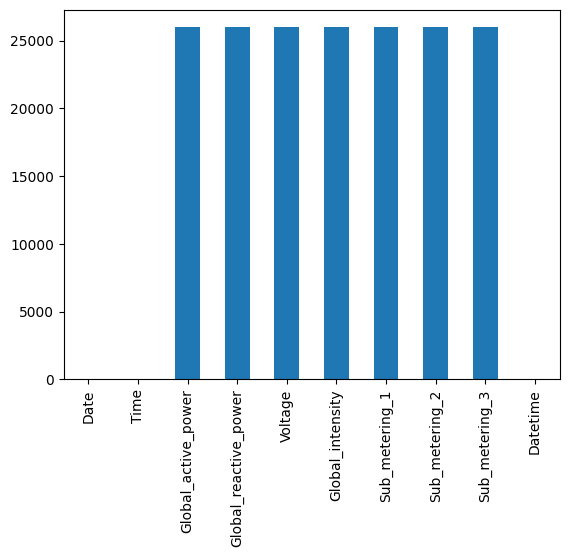

In [116]:
# Visualize missing data
df.isna().sum().plot.bar()

<Axes: xlabel='Date'>

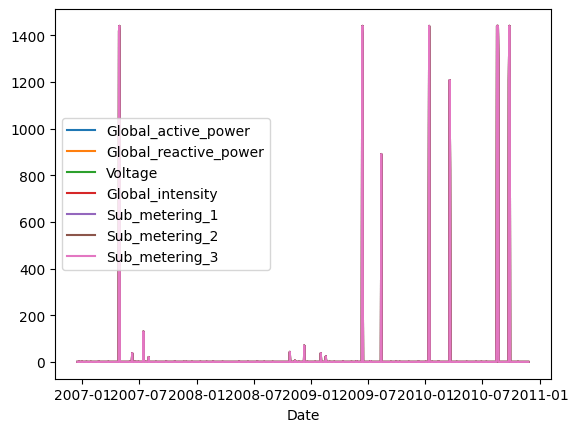

In [117]:
#https://stackoverflow.com/questions/53947196/groupby-class-and-count-missing-values-in-features
# Drop the 'Date' column and calculate missing values grouped by 'Date'
df_na = df.drop('Date', axis = 1).isna().groupby(df.Date, sort = False).sum().reset_index()

# Plot the missing values for all feature columns
df_na.plot(x='Date', y=df_na.columns[2:-1])

**Q: What do you notice about the pattern of missing data?**

A: The pattern of missing data shows that it is distributed across the numerical columns, including Global_active_power, Global_reactive_power, Voltage, Global_intensity, and Sub_metering variables. However, the Date and Time columns remain complete and without missing values. The spikes and anomalies in the visualizations suggest irregular gaps in data collection rather than systemic issues. The missing values are not tied to specific periods, indicating sporadic loss of data rather than prolonged intervals of incomplete collection.

**Q: What method makes the most sense to you for dealing with our missing data and why? (There isn't necessarily a single right answer here)**

A: Interpolation is the most appropriate method for handling the missing data in this case. As the dataset represents time-series data, it is continuous and has a strong likelihood of correlation between adjacent timestamps. Linear interpolation can fill these gaps effectively, maintaining the trends and patterns in the data without introducing substantial bias. Forward or backward filling could also work as an alternative, but interpolation ensures a smoother transition between values. Dropping rows with missing data would not be ideal, as it could lead to a significant loss of valuable information and distort the continuity of the time series.

**TODO:Use your preferred method to remove or impute a value for the missing data**

In [119]:
#clean up missing data here
# Using interpolation as the preferred method to handle missing data
# Ensuring 'Datetime' exists in the DataFrame
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Select numerical columns for interpolation
numerical_columns = df.select_dtypes(include=['number']).columns

# Perform linear interpolation to fill missing data
df[numerical_columns] = df[numerical_columns].interpolate(method='linear', inplace=False)

# Verify if all missing data has been handled
missing_values_after_cleaning = df.isna().sum()

missing_values_after_cleaning

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
Datetime,0


In [120]:
# Descriptive statistics
desc = df.describe()

#force the printout not to use scientific notation
desc[desc.columns[:-1]] = desc[desc.columns[:-1]].apply(lambda x: x.apply("{0:.4f}".format))
desc

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,2075259.0000,2075259.0000,2075259.0000,2075259.0000,2075259.0000,2075259.0000,2075259.0000,2075259
mean,1.0903,0.1236,240.8328,4.6215,1.1095,1.2892,6.4424,2008-12-06 07:12:59.999994112
min,0.0760,0.0000,223.2000,0.2000,0.0000,0.0000,0.0000,2006-12-16 17:24:00
25%,0.3100,0.0480,238.9900,1.4000,0.0000,0.0000,0.0000,2007-12-12 00:18:30
50%,0.6140,0.1000,241.0000,2.7516,0.0000,0.0000,1.0000,2008-12-06 07:13:00
75%,1.5280,0.1940,242.8700,6.4000,0.0000,1.0000,17.0000,2009-12-01 14:07:30
max,11.1220,1.3900,254.1500,48.4000,88.0000,80.0000,31.0000,2010-11-26 21:02:00
std,1.0526,0.1124,3.2378,4.4244,6.1158,5.7866,8.4159,NaN


## Visualizing the data

We're working with time series data, so visualizing the data over time can be helpful in identifying possible patterns or metrics that should be explored with further analysis and machine learning methods.

**TODO: Choose four of the variables in the dataset to visualize over time and explore methods covered in our lab session to make a line chart of the cleaned data. Your charts should be separated by variable to make them more readable.**

**Q: Which variables did you choose and why do you think they might be interesting to compare to each other over time? Remember that data descriptions are available at the data source link at the top of the assignment.**

A:
1. The **Global_active_power** variable is the overall active power that is consumed by household appliances. It's important for understanding electricity usage trends and patterns.

2. The **Voltage** variable provides insight into power supply stability. It allows us to identify anomalies that occur over time, which could impact the performance of appliances.

3. The **Global_intensity** variable measures the amperes (intensity) of electricity used. When compared to Global_active_power, it could reveal interesting correlations and patterns.

4. The **Sub_metering_3** variable measures energy consumption in specific areas or by specific appliances, such as heating systems. We can analyze its behavioral trends to determine, for instance, if there is higher heating usage during colder months.

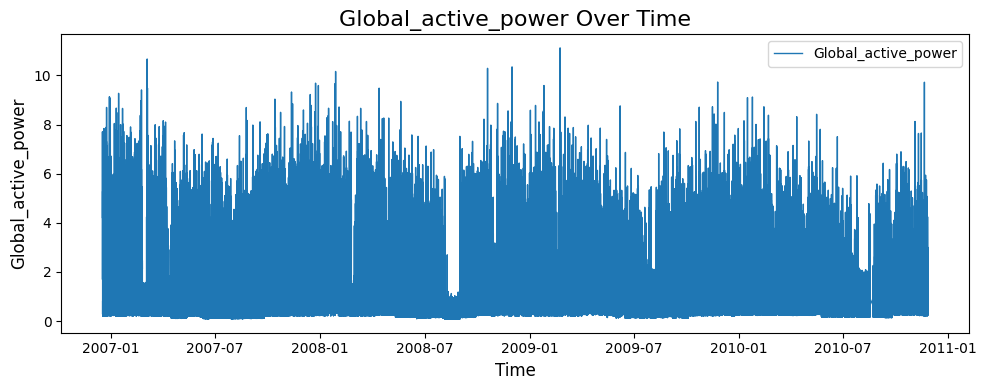

<ipython-input-159-a73e7d902982>:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


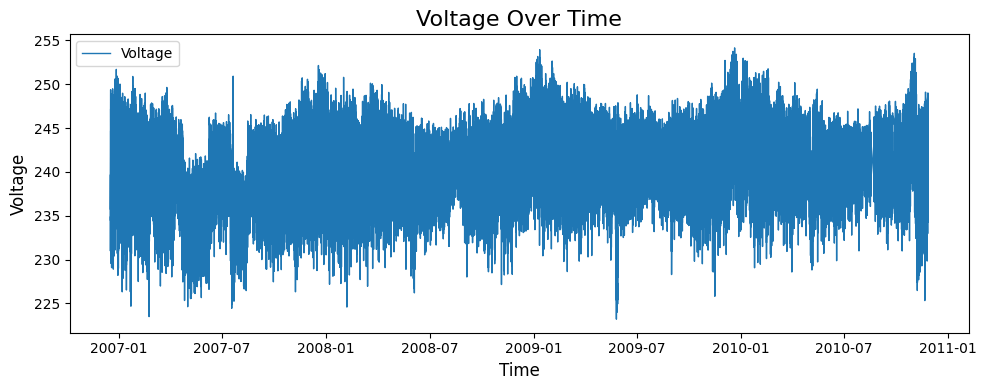

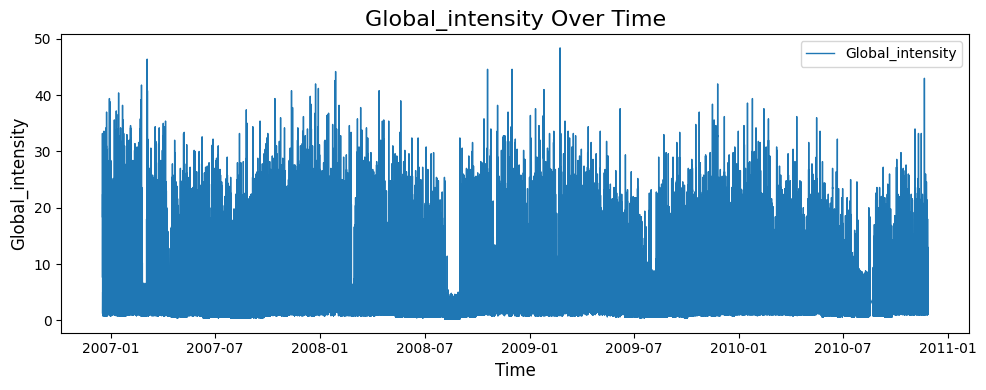

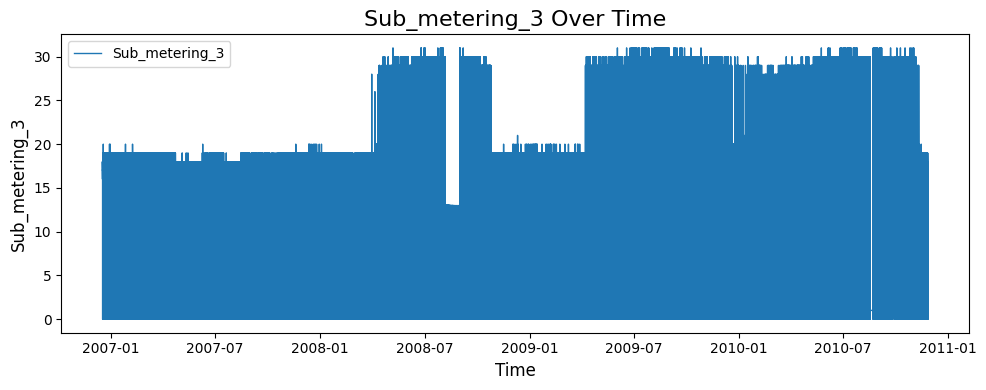

In [159]:
#build your line chart here
variables = ['Global_active_power', 'Voltage', 'Global_intensity', 'Sub_metering_3']

for var in variables:
    plt.figure(figsize=(10, 4))
    plt.plot(df['Datetime'], df[var], label=var, linewidth=1)
    plt.title(f"{var} Over Time", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel(var, fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

**Q: What do you notice about visualizing the raw data? Is this a useful visualization? Why or why not?**

A: The raw data visualization of the line charts lets us see the overall trend, anomalies, and fluctuations over time for each variable. Although it's great to observe patterns, the charts can become cluttered due to the data density which makes it hard to identify specific insights or understand exact values. To make these visualizations better, data aggregation could help make the chart easier to read.

**TODO: Compute a monthly average for the data and plot that data in the same style as above. You should have one average per month and year (so June 2007 is separate from June 2008).**

In [149]:
#compute your monthly average here
#HINT: checkout the pd.Grouper function: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Grouper.html?highlight=grouper

# Datetime column properly formatted
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Select only numeric columns to avoid issues with non-numeric data
numeric_columns = df.select_dtypes(include=['number']).columns

# Compute the monthly average using 'ME' (month-end) frequency
monthly_avg = df.groupby(pd.Grouper(key='Datetime', freq='ME'))[numeric_columns].mean().reset_index()

# Display the computed monthly averages
monthly_avg

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-31,1.901564,0.131398,241.440787,8.031087,1.251819,2.216721,7.409802
1,2007-01-31,1.546086,0.132682,240.904805,6.547142,1.264180,1.775862,7.383748
2,2007-02-28,1.401211,0.113636,240.519176,5.915104,1.180159,1.603175,6.704067
3,2007-03-31,1.318609,0.114749,240.513516,5.572905,1.361313,2.346819,6.504503
4,2007-04-30,0.845583,0.120865,239.055733,3.633866,0.974028,0.889282,4.386644
5,2007-05-31,0.985862,0.115343,235.178364,4.297464,1.696617,1.615860,5.139964
6,2007-06-30,0.827179,0.146415,238.876587,3.604947,1.381319,1.619560,4.380231
7,2007-07-31,0.668344,0.128088,237.678029,2.948938,0.964427,1.250358,3.468324
8,2007-08-31,0.764350,0.112813,237.934728,3.313421,0.812074,1.113631,5.054223
9,2007-09-30,0.969487,0.126023,239.423884,4.175329,1.223171,1.743380,5.240949


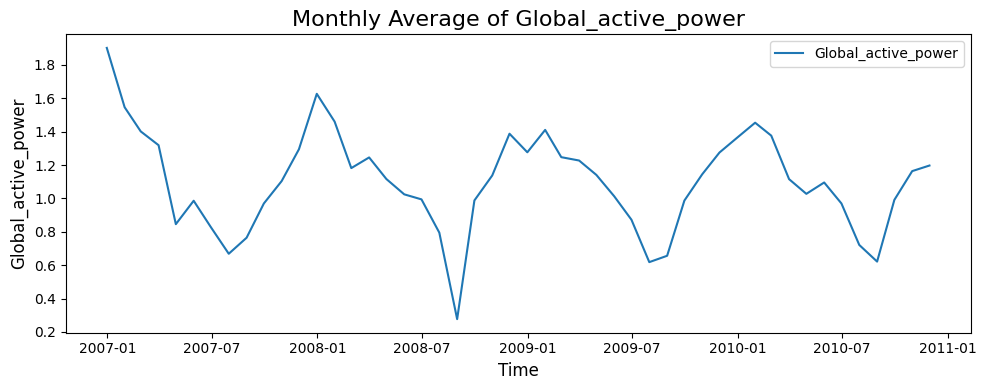

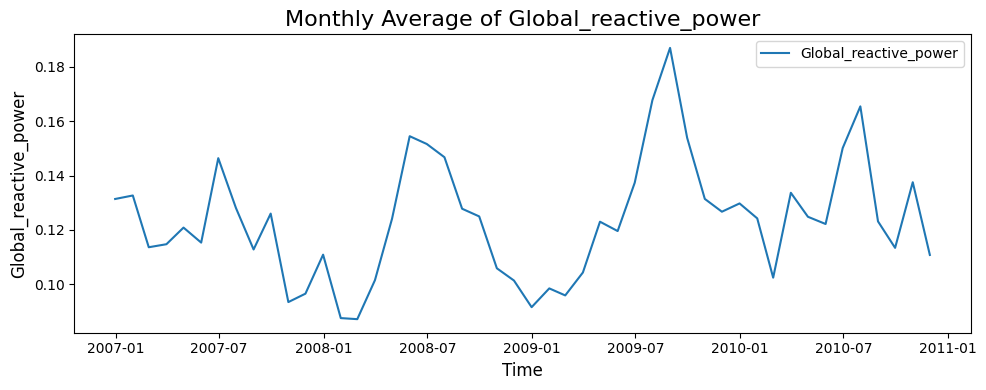

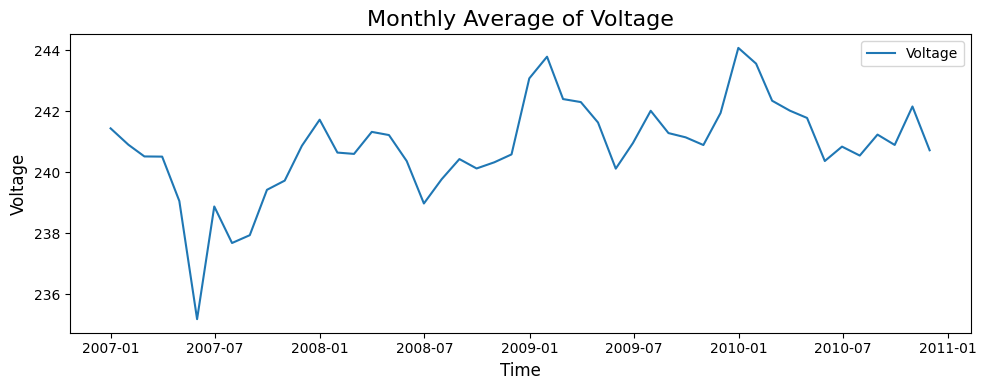

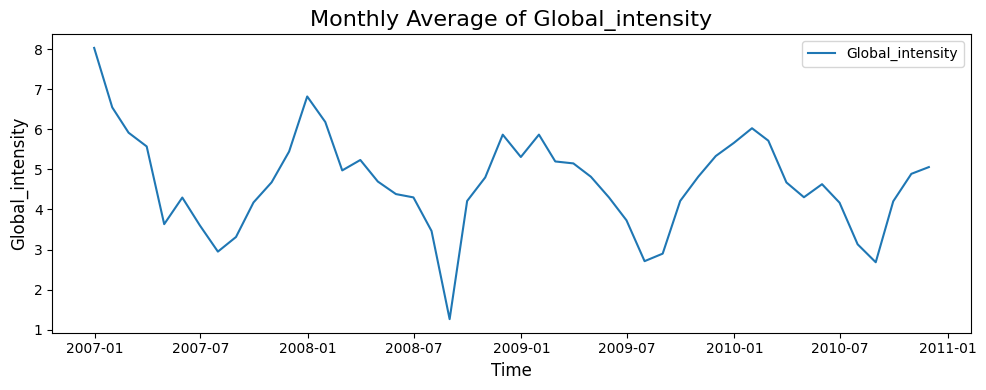

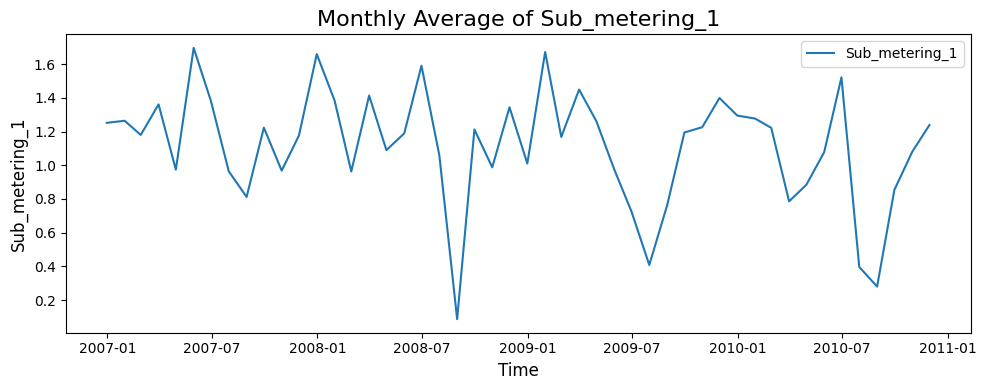

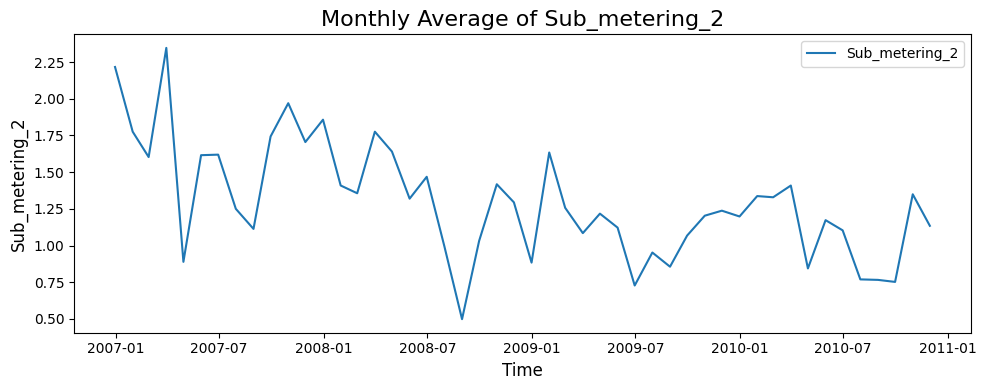

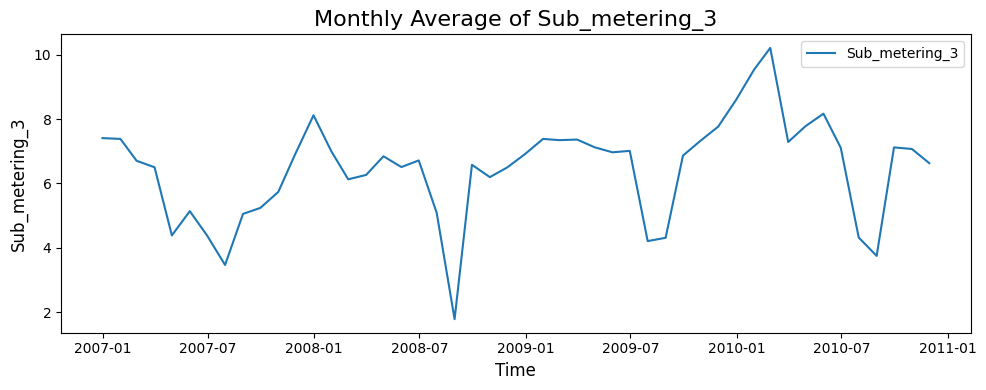

In [158]:
#build your linechart here

# Plot each numeric column in the monthly average dataframe as a line chart
for column in monthly_avg.columns[1:]:
    plt.figure(figsize=(10, 4))
    plt.plot(monthly_avg['Datetime'], monthly_avg[column], label=column, linewidth=1.5)
    plt.title(f"Monthly Average of {column}", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

**Q: What patterns do you see in the monthly data? Do any of the variables seem to move together?**

A: Global_active_power and Global_intensity exhibit similar trends, suggesting a strong relationship where higher power usage corresponds to higher current intensity. This is expected as intensity is a direct measurement tied to active power consumption. Voltage, on the other hand, follows a different trajectory, showing no significant alignment with the trends of other variables, which indicates it may provide unique and independent insights into power supply stability.

Variables such as Sub_metering_1, Sub_metering_2, and Sub_metering_3 display noticeable fluctuations that could be seasonal or application-specific, but they do not strongly correlate with each other or with other variables like Global_active_power. These variations likely reflect specific appliance usage patterns.

The parallel movements of Global_active_power and Global_intensity suggest they can complement each other in predictive tasks, but redundancy should be carefully addressed to avoid multicollinearity. Meanwhile, the independence of Voltage and the distinct behaviors of sub-metering variables highlight their potential for adding diverse insights in downstream analyses, particularly in understanding appliance-specific or voltage stability dynamics.

**TODO: Now compute a 30-day moving average on the original data and visualize it in the same style as above. Hint: If you use the rolling() function, be sure to consider the resolution of our data.**

In [152]:
#compute your moving average here

# Define the rolling window size (30 days of data)
# Assuming data is recorded at minute intervals
rolling_window = 30 * 24 * 60 // 60  # Number of data points in 30 days

# Select numeric columns for calculating the moving average
numeric_columns = df.select_dtypes(include=['number']).columns

# Compute the 30-day moving average
df_moving_avg = df.copy()
df_moving_avg[numeric_columns] = df[numeric_columns].rolling(window=rolling_window, min_periods=1).mean()

# Ensure Datetime is retained for visualization
df_moving_avg['Datetime'] = df['Datetime']

# Display the moving average DataFrame
df_moving_avg.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,2006-12-16,17:24:00,4.216000,0.418000,234.840,18.400000,0.0,1.000000,17.000000,2006-12-16 17:24:00
1,2006-12-16,17:25:00,4.788000,0.427000,234.235,20.700000,0.0,1.000000,16.500000,2006-12-16 17:25:00
2,2006-12-16,17:26:00,4.983333,0.450667,233.920,21.466667,0.0,1.333333,16.666667,2006-12-16 17:26:00
3,2006-12-16,17:27:00,5.084500,0.463500,233.875,21.850000,0.0,1.250000,16.750000,2006-12-16 17:27:00
4,2006-12-16,17:28:00,4.800800,0.476400,234.236,20.640000,0.0,1.200000,16.800000,2006-12-16 17:28:00


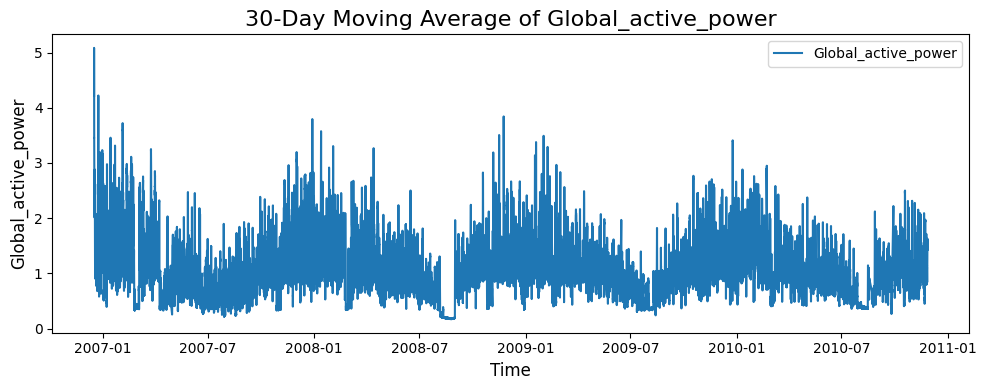

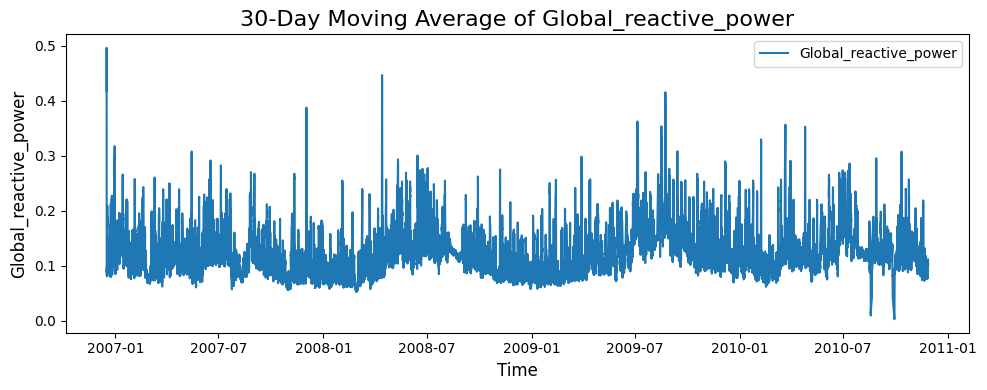

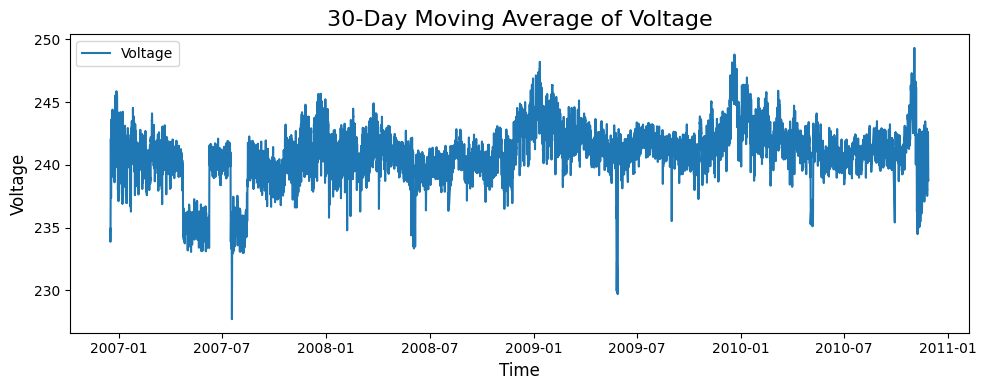

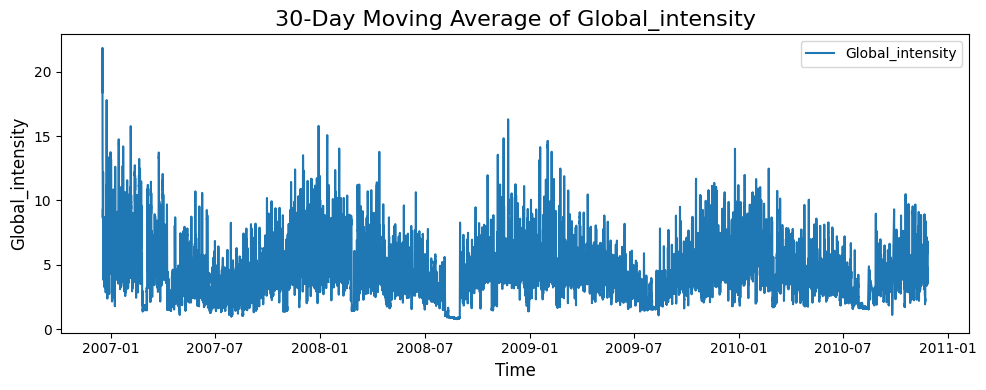

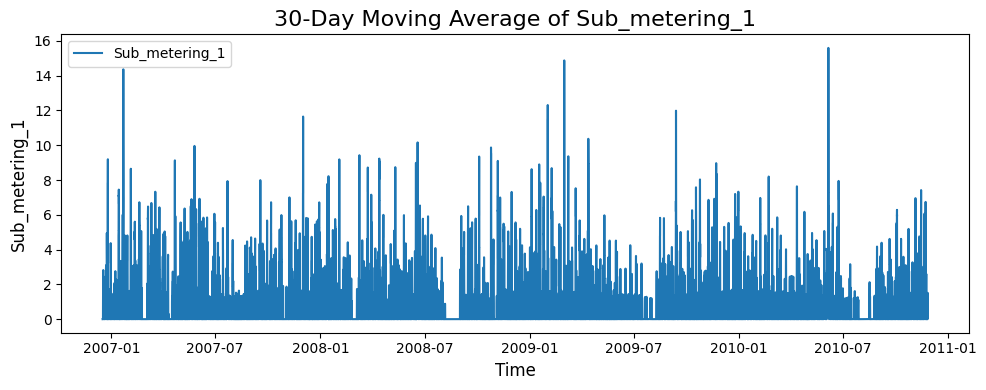

<ipython-input-157-1c3b2dcaebf4>:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


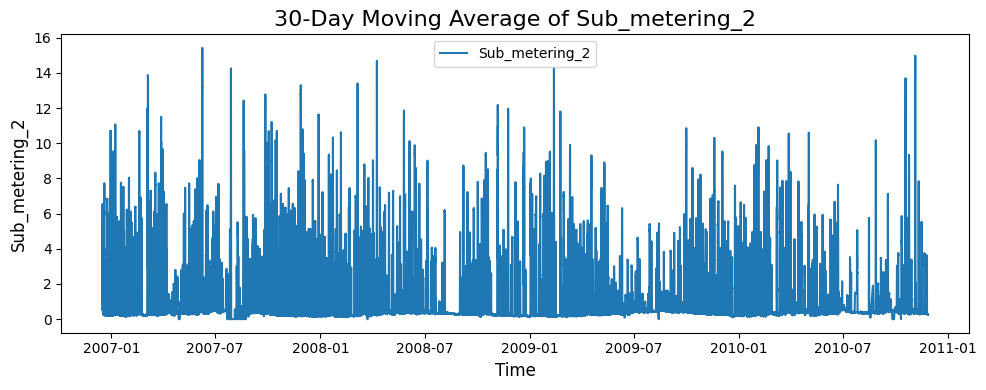

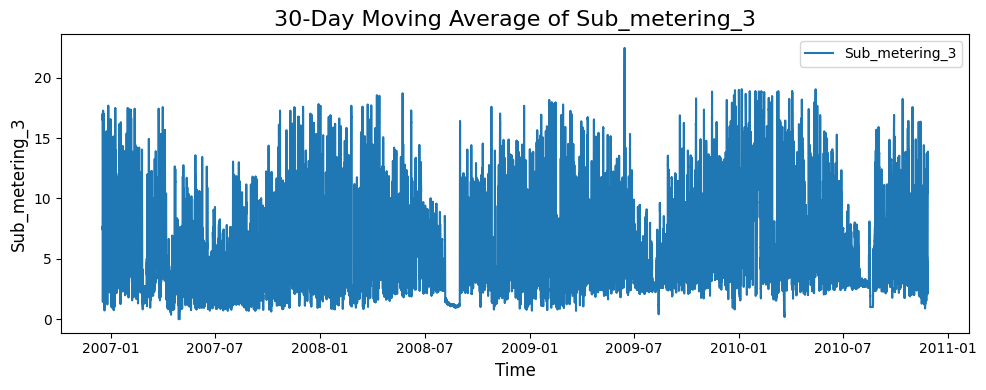

In [157]:
#build your line chart on the moving average here

# Plot each numeric column in the moving average DataFrame as a separate line chart
for column in numeric_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_moving_avg['Datetime'], df_moving_avg[column], label=column, linewidth=1.5)
    plt.title(f"30-Day Moving Average of {column}", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

**Q: How does the moving average compare to the monthly average? Which is a more effective way to visualize this data and why?**

A: The 30-day moving average and the monthly average offer distinct advantages for analyzing time-series data. The moving average smooths short-term fluctuations, providing a continuous view of trends over time. It highlights gradual changes and periodic variations without being confined to fixed intervals, making it ideal for detecting localized patterns or transitions. However, its sensitivity to short-term variability can introduce noise in datasets with frequent fluctuations. In contrast, the monthly average aggregates data into clear, defined intervals, effectively reducing noise and emphasizing long-term trends and seasonal patterns. While it simplifies the data for easier interpretation, it may overlook finer details or abrupt changes within a month. Overall, the choice depends on the analytical goal: the monthly average is more effective for understanding broad trends, while the moving average is better suited for detailed, continuous trend analysis. Both methods can be used together for a comprehensive understanding of the data.

## Data Covariance and Correlation

Let's take a look at the Correlation Matrix for the four global power variables in the dataset.

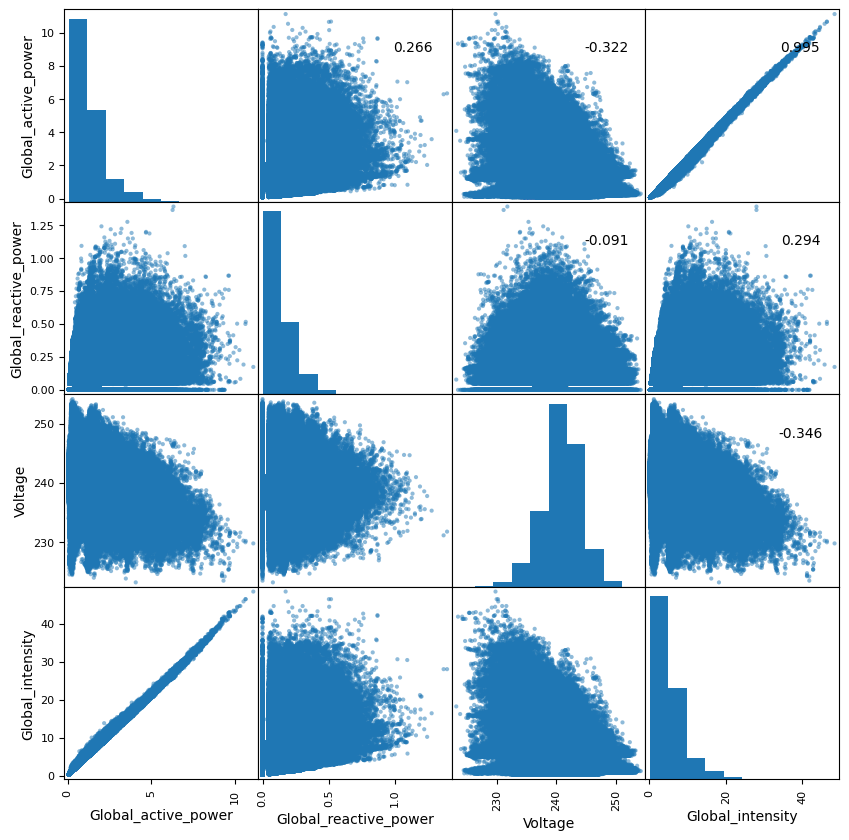

In [155]:
axes = pd.plotting.scatter_matrix(df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']], alpha=0.5,figsize = [10,10])
corr = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].corr(method = 'spearman').to_numpy() #nonlinear
for i, j in zip(*plt.np.triu_indices_from(axes, k=1)):
    axes[i, j].annotate("%.3f" %corr[i,j], (0.8, 0.8), xycoords='axes fraction', ha='center', va='center')
plt.show()

**Q: Describe any patterns and correlations that you see in the data. What effect does this have on how we use this data in downstream tasks?**

A: The data shows strong positive correlations between Global_active_power and Global_intensity, suggesting a proportional relationship between active power consumption and current intensity. Additionally, there is a moderate positive correlation between Global_active_power and Global_reactive_power, indicating some level of interdependence between active and reactive power. Conversely, Voltage exhibits a weak negative correlation with Global_active_power, meaning higher power consumption tends to slightly reduce voltage, likely due to system load. Ultimately, Voltage has minimal correlations with other variables like Global_reactive_power and Global_intensity, highlighting its relative independence from these factors.

The observed correlations have implications for downstream tasks, especially in feature engineering and model development. Strong correlations, such as between Global_active_power and Global_intensity, could lead to multicollinearity issues in predictive models, potentially skewing results or inflating variance. This calls for careful feature selection or transformation to minimize redundancy. Additionally, the weak relationships between Voltage and other variables suggest it may provide distinct, independent insights that could be valuable in modeling efforts.